# [기초-실습] 통계 101×데이터 분석: (4장) 추론통계~신뢰구간

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [ ]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
# ※ 로컬 macOS/Windows 환경에서는 아래 셀을 실행할 필요가 없습니다 (다음 셀에서 OS별로 자동 처리됩니다).
import sys
if 'google.colab' in sys.modules:
    get_ipython().system('sudo apt-get install -y fonts-nanum')
    get_ipython().system('sudo fc-cache -fv')
    get_ipython().system('rm ~/.cache/matplotlib -rf')


In [3]:
# 파이썬 라이브러리 및 모듈 가져오기
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# OS별 한글 폰트 자동 설정 (macOS: AppleGothic, Windows: Malgun Gothic, Colab/Linux: NanumGothic)
system = platform.system()
if system == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지


# 문제 1. 표본조사 체험하기

**📘 문제**

- 온라인 쇼핑몰은 전체 고객 수가 너무 많아, 모든 고객을 조사하기 어렵습니다.

- 그래서 무작위로 고객 30명을 뽑아 평균 만족도를 계산하고 이를 전체 만족도의 추정값으로 사용하려 합니다.

- 이번 실습에서는 직접 표본을 뽑고, 표본 평균을 구해보며,
  **“표본마다 결과가 달라질 수 있다”**는 추론 통계의 핵심 개념을 체험해봅니다.

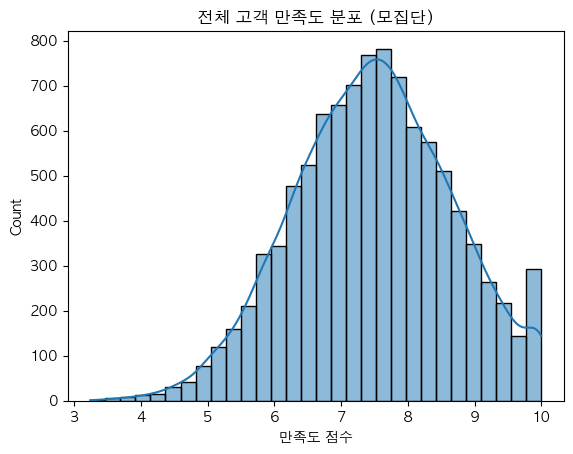

In [4]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 표본을 무작위로 여러 번 뽑아 보고, 표본 평균이 어떻게 변하는지 확인해봅시다.

- 히스토그램을 그리고, 표본 평균의 분포 형태를 관찰해봅시다.

In [24]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.
# 여기에 코드를 작성해주세요.
np.random.seed(2025)
sample = np.random.choice(df_pop['score'], size=30, replace=False)
mean_sample = sample.mean()
display("무작위 30명 :", sample)
print("표본평균 :",mean_sample)


'무작위 30명 :'

array([7.15007966, 7.7393484 , 7.03293945, 7.91313711, 6.93951644,
       5.65084442, 7.43005279, 7.17356319, 6.88374833, 6.96786101,
       8.52459225, 9.82814791, 7.77402127, 7.08677594, 5.55729163,
       7.10447556, 8.16102197, 7.92354825, 8.13035687, 7.51814866,
       5.91074111, 8.03647362, 7.84949589, 7.27527683, 7.52154547,
       8.28112575, 9.0735261 , 5.85709349, 6.91310297, 6.93441453])

표본평균 : 7.404742229332289


In [23]:
# [문제 1] Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.
# 여기에 코드를 작성해주세요.
sample_means =[]
np.random.seed(2025)
for i in range(500):
    sample = np.random.choice(df_pop['score'], size=30, replace=False)
    mean_sample = sample.mean()
    sample_means.append(mean_sample)
display("표본평균 리스트 :", sample_means)

'표본평균 리스트 :'

[np.float64(7.404742229332289),
 np.float64(7.701406541303069),
 np.float64(7.334755612071231),
 np.float64(7.575267003846345),
 np.float64(7.646782651114237),
 np.float64(7.273462551326532),
 np.float64(7.421399243043869),
 np.float64(7.453924233422445),
 np.float64(7.68852275076122),
 np.float64(7.601368972387283),
 np.float64(7.20557395292238),
 np.float64(7.022036487163065),
 np.float64(7.5339688466594685),
 np.float64(7.205268560076575),
 np.float64(7.3142084393330675),
 np.float64(7.747411413860209),
 np.float64(7.332953931860411),
 np.float64(7.800057912706262),
 np.float64(7.530470369072374),
 np.float64(7.7114171407072964),
 np.float64(7.28409216325463),
 np.float64(7.5065744804083145),
 np.float64(7.589710883013153),
 np.float64(7.259820138089935),
 np.float64(7.56486518172912),
 np.float64(7.5769415155292545),
 np.float64(7.681181795527404),
 np.float64(7.607566318152822),
 np.float64(7.420179981022191),
 np.float64(7.664009818403658),
 np.float64(7.674838050204027),
 np.flo

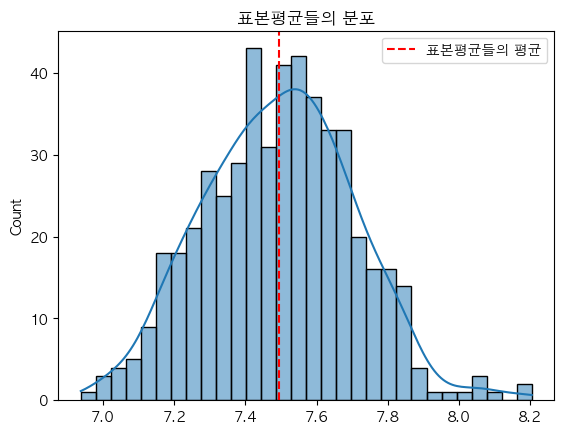

In [ ]:
# [문제 1] Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
# 여기에 코드를 작성해주세요.
sns.histplot(sample_means, bins=30, kde=True)
plt.title("표본평균들의 분포")
plt.axvline(np.mean(sample_means), color='red', linestyle='--', label='표본평균들의 평균')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?

- 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요

- 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?

- 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?

### [문제 1] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 표본 평균들은 7.4와 7.6 사이에 몰려있고, 전체 모집단 평균과 거의 일치한다.
- 1번만 뽑으면 모평균과 얼마나 가까운지 모르기에 500번 반복하는게 더 신뢰성있다.
- 같은 평균이 나오지 않았을 것이다. 30명을 무작위로 뽑는것이기 때문에 평균은 항상 다르게 나온다.
- 종 모양의 정규분포처럼 보인다. 중심극한정리 때문에 정규분포에 가까워진것이다.

# 문제 2. 중심극한정리

**📘 문제**

- 현실에서는 모집단의 분포가 정규분포가 아닐 수도 있습니다.

- 예를 들어, 일부 고객은 매우 높은 점수를 주고, 대부분은 낮은 점수를 주는 만족도 분포가 있을 수 있죠. (예: 지수분포)

- 이처럼 원래 분포가 비정규분포여도,
  표본을 여러 번 뽑아 평균을 계산하면, 그 평균들의 분포는 정규분포에 가까워진다는 것을
  **중심극한정리(Central Limit Theorem)**라고 합니다.

- 이번 실습에서는 다양한 크기의 표본을 뽑아 평균을 계산하고,
  그 평균들의 분포가 어떻게 변하는지를 직접 실험해 봅니다.

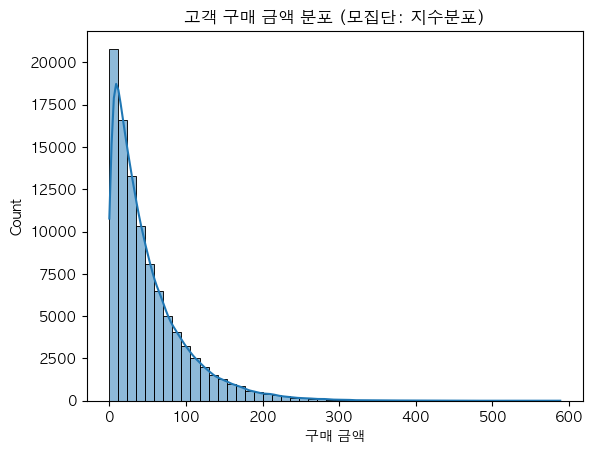

In [26]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

**📌 아래를 수행해 보세요:**

- 비대칭적인 모집단(지수분포)에서 무작위로 표본을 추출해 평균을 구해봅시다.

- 표본 크기를 바꿔가며, 표본 평균들의 분포가 어떻게 변화하는지 확인해봅시다.

- 히스토그램을 그리고, 분포의 모양을 관찰해봅시다.

- 표본 크기가 커질수록 표본 평균 분포의 모양과 **퍼진 정도(분산)**가 어떻게 변하는지 관찰해봅시다.

In [36]:
# [문제 2] Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5일 때

# 여기에 코드를 작성해주세요.
sample_means_5  =[]
np.random.seed(2025)
for i in range(1000):
    sp_1 = np.random.choice(population, size=5, replace=False)
    mean_sample_1 = sp_1.mean()
    sample_means_5 .append(mean_sample_1)
print("표본크기 5")
display(sample_means_5 )


표본크기 5


[np.float64(43.538739156766404),
 np.float64(77.52498444951523),
 np.float64(42.25625665781945),
 np.float64(17.03338264925393),
 np.float64(35.482384806834595),
 np.float64(55.48693750214193),
 np.float64(32.105460204208626),
 np.float64(83.53733076514166),
 np.float64(82.04878564460441),
 np.float64(47.58801335371423),
 np.float64(50.93040131948478),
 np.float64(56.12210644918491),
 np.float64(61.213231924989785),
 np.float64(62.45368211046434),
 np.float64(44.67217563351924),
 np.float64(24.934319233590127),
 np.float64(68.9844659475086),
 np.float64(41.63406942456211),
 np.float64(60.30914356853002),
 np.float64(48.2718454179385),
 np.float64(48.11943499838323),
 np.float64(40.792510348290435),
 np.float64(56.05903957286296),
 np.float64(129.80566524272868),
 np.float64(47.116661613135655),
 np.float64(50.29288117722647),
 np.float64(61.11260811681633),
 np.float64(110.48724109440039),
 np.float64(110.93580891977267),
 np.float64(81.64242042648257),
 np.float64(57.480780317695896),

In [35]:
# [문제 2] Q2. 위 과정을 표본 크기 30, 100일 때도 반복해봅시다.
# sample_size = 30, 100
sample_means_30  =[]
np.random.seed(2025)
for i in range(1000):
    sp_1 = np.random.choice(population, size=30, replace=False)
    mean_sample_1 = sp_1.mean()
    sample_means_30 .append(mean_sample_1)
print("표본크기 30")
display(sample_means_30 )

sample_means_100  =[]
np.random.seed(2025)
for i in range(1000):
    sp_1 = np.random.choice(population, size=100, replace=False)
    mean_sample_1 = sp_1.mean()
    sample_means_100 .append(mean_sample_1)
print("표본크기 100")
display(sample_means_100 )


# 여기에 코드를 작성해주세요.

표본크기 30


[np.float64(49.77728357597778),
 np.float64(83.5443227327726),
 np.float64(48.704891121398255),
 np.float64(39.68796928553404),
 np.float64(48.77869117666066),
 np.float64(48.96034168645497),
 np.float64(42.35643165494605),
 np.float64(45.741821893848545),
 np.float64(62.235958300530356),
 np.float64(36.496435883038735),
 np.float64(57.19147475575853),
 np.float64(53.08521213124652),
 np.float64(53.75857774332785),
 np.float64(60.30765809358129),
 np.float64(44.36582146319195),
 np.float64(46.34802072217069),
 np.float64(54.8457555599366),
 np.float64(52.1341423793086),
 np.float64(45.60838176355252),
 np.float64(70.35355365407996),
 np.float64(37.13924959154452),
 np.float64(59.88815022889908),
 np.float64(53.55132777729928),
 np.float64(58.51534088127489),
 np.float64(48.42856378170323),
 np.float64(54.39920959261099),
 np.float64(46.91790847518736),
 np.float64(52.423329576359926),
 np.float64(61.51874668034433),
 np.float64(46.47539514869632),
 np.float64(65.48181078146682),
 np.fl

표본크기 100


[np.float64(52.350706596541066),
 np.float64(62.81867416651663),
 np.float64(52.22252450546225),
 np.float64(47.73675794992202),
 np.float64(45.7496608649973),
 np.float64(45.41709403182958),
 np.float64(56.42649170101874),
 np.float64(44.70423069501784),
 np.float64(56.60305396244762),
 np.float64(41.98114997618065),
 np.float64(54.84359559551224),
 np.float64(55.97672379460447),
 np.float64(57.391389586240436),
 np.float64(45.18013676798742),
 np.float64(56.81735235428924),
 np.float64(42.617894128572374),
 np.float64(47.633484809428055),
 np.float64(50.77001320989407),
 np.float64(51.68844543312259),
 np.float64(70.66793457313167),
 np.float64(43.094863848535994),
 np.float64(56.72408957456023),
 np.float64(65.18634202829006),
 np.float64(49.48088243361639),
 np.float64(49.00099966236687),
 np.float64(51.43868042467757),
 np.float64(49.432365610658564),
 np.float64(60.178724346261504),
 np.float64(55.69416847823169),
 np.float64(48.793377526097835),
 np.float64(50.5723677447915),
 n

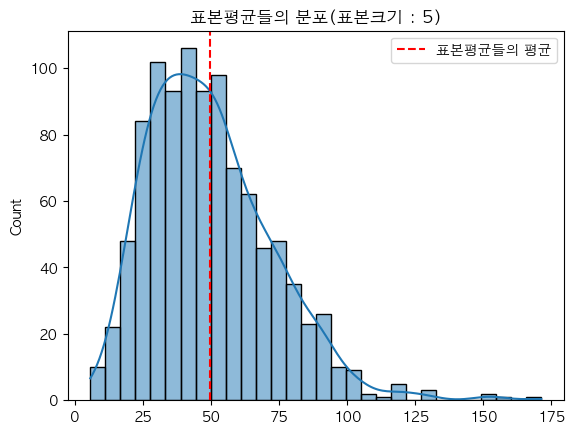

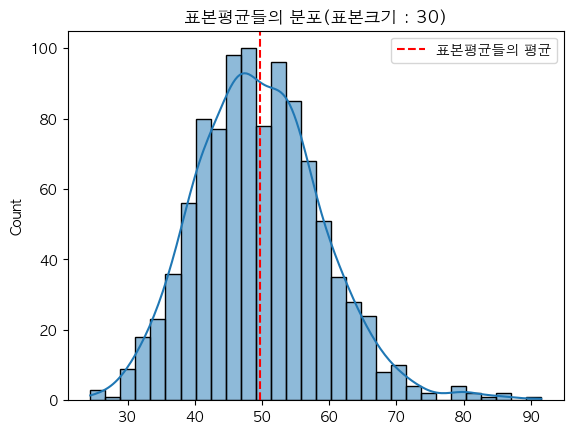

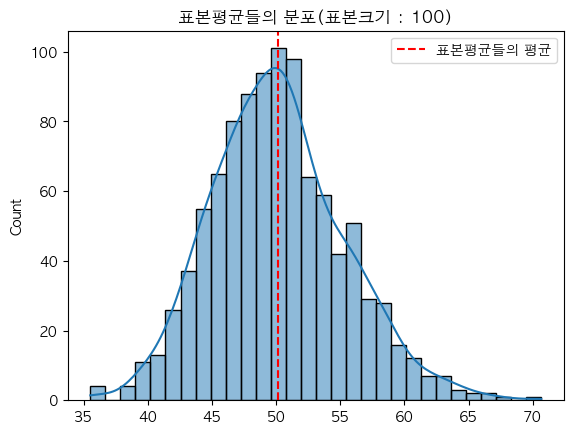

In [38]:
# [문제 2] Q3. 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 평균선을 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

sns.histplot(sample_means_5, bins=30, kde=True)
plt.title("표본평균들의 분포(표본크기 : 5)")
plt.axvline(np.mean(sample_means_5), color='red', linestyle='--', label='표본평균들의 평균')
plt.legend()
plt.show()

sns.histplot(sample_means_30, bins=30, kde=True)
plt.title("표본평균들의 분포(표본크기 : 30)")
plt.axvline(np.mean(sample_means_30), color='red', linestyle='--', label='표본평균들의 평균')
plt.legend()
plt.show()

sns.histplot(sample_means_100, bins=30, kde=True)
plt.title("표본평균들의 분포(표본크기 : 100)")
plt.axvline(np.mean(sample_means_100), color='red', linestyle='--', label='표본평균들의 평균')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?

- 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?

- 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?

- 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?

- 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?

### [문제 2]데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 오른쪽 꼬리가 긴 모양이다. 
- 커질수록 정규분포와 비슷하게 종 모양이 되어간다.
- 표본 크기가 커질수록 표본평균은 여러개의 값을 더해서 나눈 것이기 때문에 우연히 뽑힌 큰 값과 작은값들이 서로 상쇄돼서 원래 모집단이 비대칭이었는데도 표본크기가 커질수록 평균들의 분포가 정규분포처럼 바뀌는것이다.
- 히스토그램을 통해 표본크기가 커질수록 정규분포와 같은 종모양 그래프가 나오는 것을 보고 중심극한저일를 이해하게 되었다.
- 표본 크기가 커질수록 분포의 넓이는 좁아진다.

# 문제 3. 표준오차

**📘 문제**

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.

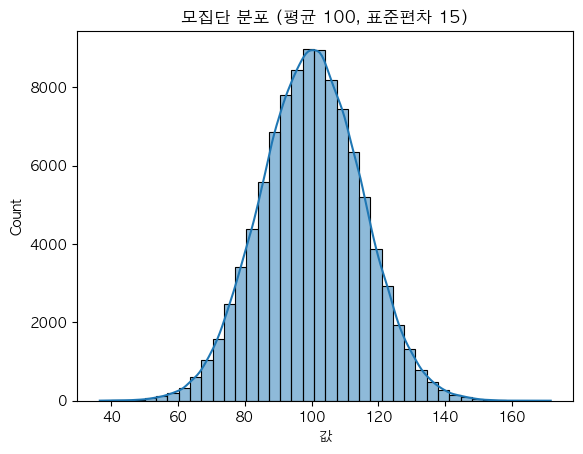

In [39]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

In [ ]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.
def get_sample_means(n, repeat=1000):
    np.random.seed(2025)
    return [np.random.choice(population, size=n, replace=False).mean() for i in range(repeat)]

sample_sizes = [10, 30, 100, 500]
sample_means_dict = {n: get_sample_means(n) for n in sample_sizes}

experimental_se = [np.std(sample_means_dict[n]) for n in sample_sizes]

df_se = pd.DataFrame({
    "표본크기": sample_sizes,
    "실험적_표준오차": experimental_se
})
df_se


# 여기에 코드를 작성해주세요.

,표본크기,실험적_표준오차
0,10,4.558660
1,30,2.689713
2,100,1.477130
3,500,0.661012


In [45]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

# 여기에 코드를 작성해주세요.
theoretical_se = [population.std() / np.sqrt(n) for n in sample_sizes]

df_se["이론적_표준오차"] = theoretical_se
df_se


,표본크기,실험적_표준오차,이론적_표준오차
0,10,4.558660,4.753921
1,30,2.689713,2.744677
2,100,1.477130,1.503322
3,500,0.661012,0.672306


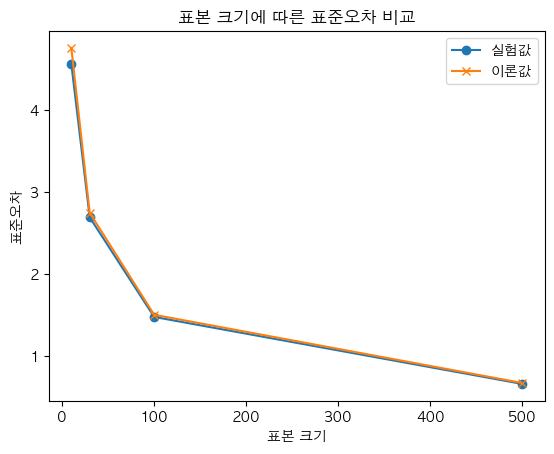

In [46]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

# 여기에 코드를 작성해주세요.
plt.plot(df_se["표본크기"], df_se["실험적_표준오차"], marker='o', label='실험값')
plt.plot(df_se["표본크기"], df_se["이론적_표준오차"], marker='x', label='이론값')
plt.title("표본 크기에 따른 표준오차 비교")
plt.xlabel("표본 크기")
plt.ylabel("표준오차")
plt.legend()
plt.show()


**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?

- 왜 표본 크기가 커질수록 표준오차는 작아질까요?

### [문제 3] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 표본 크기가 작을수록 표본오차가 크기때문에 표본 평균의 분포는 넓게 퍼져있다.
- 표본 크기가 커질수록 평균 분포는 좁게 변한다.
- 실험값과 이론값은 거의 일치한다.
- 표준오차 공식 `SE = σ / √n`에 따르면 n이 표본 크기인데 n이 커질수록 √n도 커지고, σ를 더 큰 수로 나누게 되니까 SE는 작아지게 된다.


# 문제 4. 신뢰구간 계산과 해석

**📘 문제**

- 표본 평균은 모집단 평균을 추정하는 좋은 점 추정(Point Estimation) 값이지만, 표본오차 때문에 정확히 일치하지는 않습니다.

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간으로 추정(Interval Estimation)**하는 것이 더 합리적입니다. 이때 사용하는 개념이 바로 **신뢰구간(Confidence Interval)**입니다.

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정됩니다.

- 이번 실습에서는 **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인해봅니다.

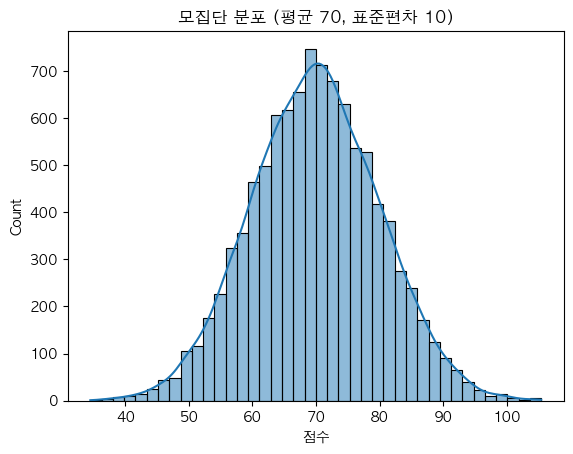

In [47]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 30명을 무작위로 뽑아 평균, 표준편차, 표준오차를 계산해보세요.

- 95% 신뢰구간을 z-분포와 t-분포를 각각 사용해서 계산해보세요.

- 신뢰수준을 바꿨을 때(90%, 99%) 신뢰구간이 어떻게 변하는지 확인해보세요.

In [48]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(2025)
sample = np.random.choice(population, size=30, replace=False)
mean_sample = sample.mean()
std_sample = sample.std(ddof=1)
se_sample = std_sample / np.sqrt(30)
display("무작위 30명 :", sample)
print("표본평균 :",mean_sample)
print("표본표준편차 :", std_sample)
print("표준오차 :", se_sample)


'무작위 30명 :'

array([67.08399719, 71.99457001, 66.10782876, 73.44280922, 65.32930363,
       54.59037016, 69.41710655, 67.27969329, 64.86456938, 65.56550845,
       78.53826879, 89.40123259, 72.28351062, 66.55646619, 53.81076362,
       66.70396301, 75.50851639, 73.52956873, 75.25297394, 70.1512388 ,
       56.75617591, 74.47061354, 72.91246572, 68.12730694, 70.17954561,
       76.50938129, 83.11271747, 56.30911244, 65.10919138, 65.28678771])

표본평균 : 69.20618524443573
표본표준편차 : 7.875499169121773
표준오차 : 1.4378628488470628


In [49]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 여기에 코드를 작성해주세요.
from scipy import stats

sigma = population.std()          # 모표준편차 (안다고 가정)
n = 30
se_z = sigma / np.sqrt(n)         # 표준오차 (모표준편차 기준)

z_value = stats.norm.ppf(0.975)  # 95% 신뢰수준 → 양쪽 꼬리 2.5%씩 남기는 지점
margin = z_value * se_z          # 오차범위(margin of error)

ci_lower = mean_sample - margin
ci_upper = mean_sample + margin

print("z값 :", z_value)
print("오차범위 :", margin)
print(f"95% 신뢰구간 (z-분포) : [{ci_lower:.3f}, {ci_upper:.3f}]")

z값 : 1.959963984540054
오차범위 : 3.580212265830728
95% 신뢰구간 (z-분포) : [65.626, 72.786]


In [50]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 여기에 코드를 작성해주세요.
std_sample = sample.std(ddof=1)
n = 30

se_t = std_sample / np.sqrt(n)
t_value = stats.t.ppf(0.975, df=n-1)   # 자유도 = n-1 = 29
margin_t = t_value * se_t

ci_lower_t = mean_sample - margin_t
ci_upper_t = mean_sample + margin_t

print("t값 :", t_value)
print("오차범위 :", margin_t)
print(f"95% 신뢰구간 (t-분포) : [{ci_lower_t:.3f}, {ci_upper_t:.3f}]")



t값 : 2.045229642132703
오차범위 : 2.940759719783387
95% 신뢰구간 (t-분포) : [66.265, 72.147]


In [51]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

# 여기에 코드를 작성해주세요.
confidence_levels = [0.90, 0.95, 0.99]
rows = []
for cl in confidence_levels:
    alpha = 1 - cl
    t_val = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_val * se_t
    rows.append({
        "신뢰수준": cl,
        "t값": t_val,
        "오차범위": margin,
        "하한": mean_sample - margin,
        "상한": mean_sample + margin,
        "구간폭": 2 * margin
    })

df_ci = pd.DataFrame(rows)
df_ci


,신뢰수준,t값,오차범위,하한,상한,구간폭
0,0.90,1.699127,2.443112,66.763074,71.649297,4.886223
1,0.95,2.045230,2.940760,66.265426,72.146945,5.881519
2,0.99,2.756386,3.963305,65.242880,73.169490,7.926610


**🧠 데이터를 어떻게 읽을까요?**

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?

- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?

### [문제 4] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- z-분포는 [65.626, 72.786], t-분포는 [66.265, 72.147]로 나왔다.
- 신뢰수준이 높아질수록 신뢰구간의 폭은 넓어진다. 더 높은 신뢰수준을 원할수록 넓은 범위를 잡아야 안전하기 때문이다.
- 좋다 나쁘다라고 말할 수 없다. 신뢰구간이 넓을수록 정밀도는 하락하고, 신뢰구간이 좁을수록 정밀도는 높아진다. 적당히 균형을 맞춰야한다.
- 신뢰구간이 좁고 하한값이 충분이 높다면 긍정적으로 마케팅을 진행할 수 있다.

# 문제 5. 미니 프로젝트 - 고객 만족도 신뢰구간 추정

**📘 문제**

- 전체 고객 10,000명을 대상으로 만족도 조사를 하는 것은 시간과 비용이 많이 듭니다.
- 그래서 우리는 무작위로 일부 고객만 조사하여, 전체 고객의 평균 만족도를 추정하려 합니다.

- 이 프로젝트에서는 실제와 같은 상황을 가정하여, 표본을 뽑고 신뢰구간을 계산한 뒤, 이 결과를 바탕으로 마케팅 전략에 어떻게 활용할 수 있을지까지 생각해보는 실습을 진행합니다.

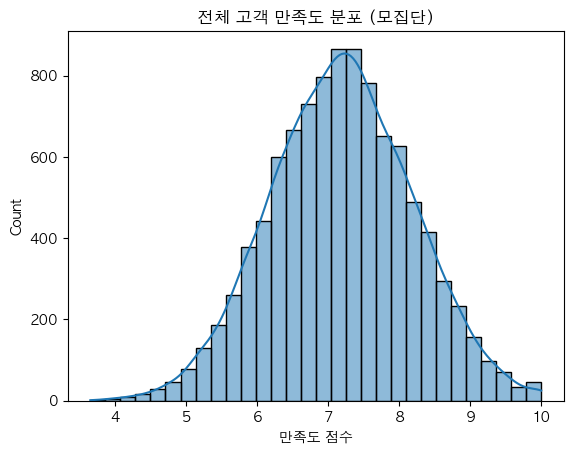

In [52]:
# 모집단 생성 (고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)

# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단을 생성하고, 거기서 표본을 40명 뽑아 평균을 계산해봅시다.

- 표본 평균과 표준편차를 바탕으로 95% 신뢰구간을 계산해봅시다.

- 히스토그램을 그리고 신뢰구간을 시각화해봅시다.

- 이 결과를 어떻게 해석하고, 마케팅 전략에 활용할 수 있을지 생각해봅시다.

In [53]:
# [문제 5] Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 여기에 코드를 작성해주세요.
np.random.seed(2025)
sample = np.random.choice(population, size=40, replace=False)
mean_sample = sample.mean()
std_sample = sample.std(ddof=1)
print("표본평균 :", mean_sample)
print("표본표준편차 :", std_sample)


표본평균 : 7.225809160271515
표본표준편차 : 0.8972963814022722


In [54]:
# [문제 5] Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
# 여기에 코드를 작성해주세요.
from scipy import stats

n = 40
se = std_sample / np.sqrt(n)
t_value = stats.t.ppf(0.975, df=n-1)
margin = t_value * se

ci_lower = mean_sample - margin
ci_upper = mean_sample + margin
print("표준오차 :", se)
print(f"95% 신뢰구간 : [{ci_lower:.3f}, {ci_upper:.3f}]")


표준오차 : 0.14187501507291653
95% 신뢰구간 : [6.939, 7.513]


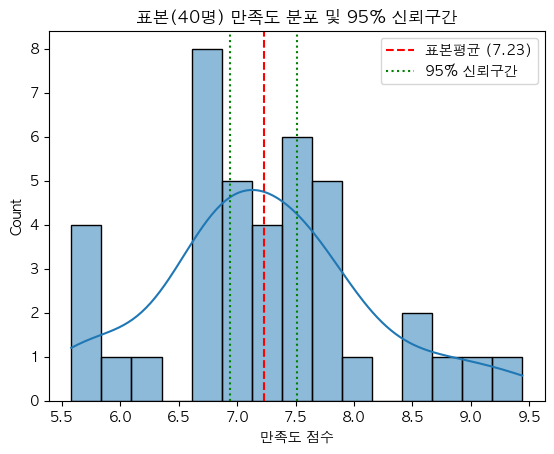

In [55]:
# [문제 5] Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.
#  여기에 코드를 작성해주세요.
sns.histplot(sample, bins=15, kde=True)
plt.axvline(mean_sample, color='red', linestyle='--', label=f'표본평균 ({mean_sample:.2f})')
plt.axvline(ci_lower, color='green', linestyle=':', label='95% 신뢰구간')
plt.axvline(ci_upper, color='green', linestyle=':')
plt.title("표본(40명) 만족도 분포 및 95% 신뢰구간")
plt.xlabel("만족도 점수")
plt.legend()
plt.show()


### [문제 5] Q4. 신뢰구간의 결과에 따라 어떤 구체적인 마케팅 전략을 세울 수 있을까요?
#### 여기에 의견을 작성해주세요.
95% 신뢰구간이 [6.94, 7.51]로, 하한값이 약 7점에 가깝다. 
최소 7점 안팎의 만족도는 확보하고 있다고 어느 정도 확신할 수 있으므로, 
"고객 만족도 7점 이상"과 같은 문구를 마케팅에 활용할 수 있다. 
다만 구간의 폭(약 0.57점)이 크지 않은 편은 아니므로, 
표본을 더 늘려 추정을 정밀화하면 더 구체적인 수치(예: "평균 7.2점")를 자신 있게 내세울 수 있을 것이다.

**🧠 데이터를 어떻게 읽을까요?**

- 신뢰구간은 몇 점에서 몇 점 사이인가요?

- 이 구간은 전체 모집단 평균을 포함하고 있나요?

- 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?

- 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?

### [문제 5] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 95% 신뢰구간은 약 6.94점 ~ 7.51점 사이이다.
- 포함하고있다.
- 10점만점 기준 7점 초반대이므로 보통 이상이지만 높다고 하기엔 애매하다.
- 신뢰구간이 넓어지는 이유는 표본 크기가 작거나 표준편차가 크기 때문이다. 개선하려면 표본 크기를 늘려야한다.